## Importing necessary libraries

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from wordcloud import WordCloud
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Setting visualization styles
sns.set(style="whitegrid")
plt.style.use('fivethirtyeight')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/armanabrahamyan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/armanabrahamyan/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/armanabrahamyan/nltk_data...


## Load the Data

In [45]:
import sys
sys.path.append('../src/')

from data_loader import load_data

train_data = load_data('../data/raw/train.csv')
test_data = load_data('../data/raw/test.csv')

Overview

In [49]:
print("Training Data:")
print(train_df.head())
print("\nTest Data:")
print(test_df.head())

# Checking for missing values
print("\nMissing values in Training Data:", train_df.isnull().sum())
print("\nMissing values in Test Data:", test_df.isnull().sum())

Training Data:
                                              review sentiment  review_length
0  I caught this little gem totally by accident b...  positive            892
1  I can't believe that I let myself into this mo...  negative            937
2  *spoiler alert!* it just gets to me the nerve ...  negative            468
3  If there's one thing I've learnt from watching...  negative           1960
4  I remember when this was in theaters, reviews ...  negative           1015

Test Data:
                                              review sentiment
0  Yes, MTV there really is a way to market Daria...  negative
1  The story of the bride fair is an amusing and ...  negative
2  A team varied between Scully and Mulder, two o...  positive
3  This was a popular movie probably because of t...  negative
4  This movie made me so angry!! Here I am thinki...  negative

Missing values in Training Data: review           0
sentiment        0
review_length    0
dtype: int64

Missing values in Test

/Users/armanabrahamyan/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/armanabrahamyan/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/armanabrahamyan/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


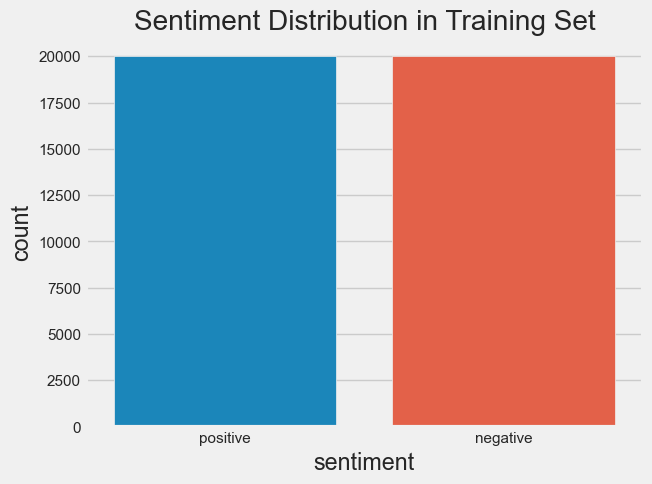

In [48]:
if 'sentiment' in train_df.columns:
    sns.countplot(x='sentiment', data=train_df)
    plt.title('Sentiment Distribution in Training Set')
    plt.show()

Text Length Distribution

/Users/armanabrahamyan/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/armanabrahamyan/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/armanabrahamyan/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/armanabrahamyan/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a fu

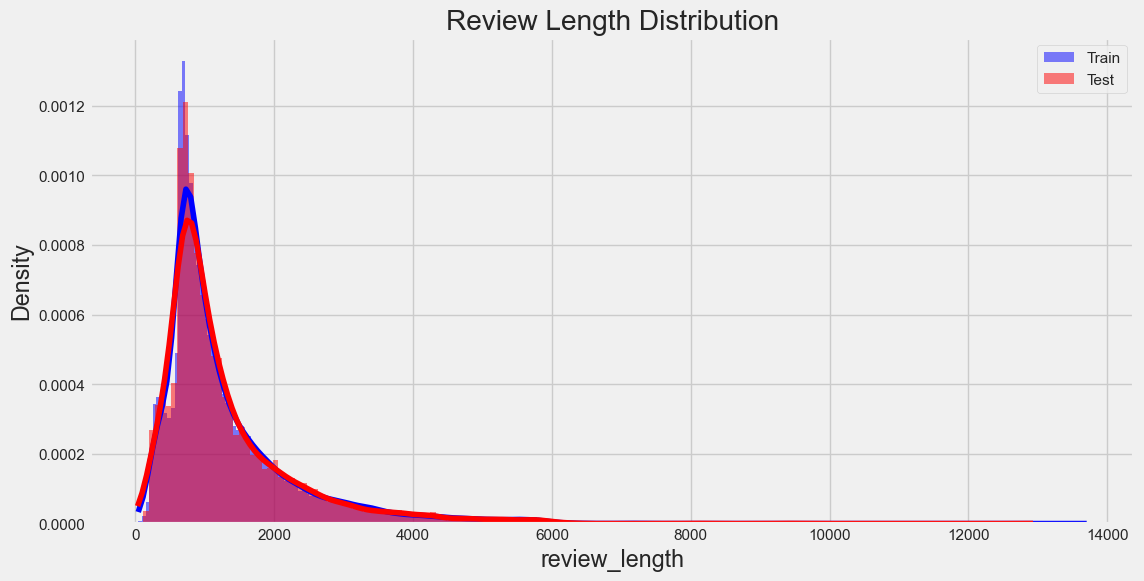

In [50]:
train_df['review_length'] = train_df['review'].apply(len)
test_df['review_length'] = test_df['review'].apply(len)

plt.figure(figsize=(12, 6))
sns.histplot(train_df['review_length'], color='blue', label='Train', kde=True, stat="density", linewidth=0)
sns.histplot(test_df['review_length'], color='red', label='Test', kde=True, stat="density", linewidth=0)
plt.title('Review Length Distribution')
plt.legend()
plt.show()

## Text Preprocessing

### Tokenization

In [53]:
sample_text = train_df['review'].iloc[0]
sample_tokens = word_tokenize(sample_text)
print("Tokens:", sample_tokens[:10])

Tokens: ['I', 'caught', 'this', 'little', 'gem', 'totally', 'by', 'accident', 'back', 'in']


Tokenization used for breaking down texts into manageable units for analysis.

### Stop-Words Filtering

In [54]:
stop_words = set(stopwords.words('english'))
filtered_tokens = [w for w in sample_tokens if not w in stop_words]
print("Filtered Tokens:", filtered_tokens[:10])

Filtered Tokens: ['I', 'caught', 'little', 'gem', 'totally', 'accident', 'back', '1980', "'81", '.']


Filtering stop words can help focus on more meaningful words for analysis.

### Stemming vs Lemmatization

In [55]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

stemmed_words = [stemmer.stem(word) for word in filtered_tokens]
lemmatized_words = [lemmatizer.lemmatize(word) for word in filtered_tokens]

# The difference
print("Stemmed:", stemmed_words[:10])
print("Lemmatized:", lemmatized_words[:10])

Stemmed: ['i', 'caught', 'littl', 'gem', 'total', 'accid', 'back', '1980', "'81", '.']
Lemmatized: ['I', 'caught', 'little', 'gem', 'totally', 'accident', 'back', '1980', "'81", '.']


Stemming simplifies words to their base forms, sometimes leading to incomplete words, while lemmatization returns full words with similar meaning, providing more readable results.

### Vectorization

In [56]:
count_vect = CountVectorizer(stop_words='english')
X_train_counts = count_vect.fit_transform(train_df['review'])

tfidf_vect = TfidfVectorizer(stop_words='english')
X_train_tfidf = tfidf_vect.fit_transform(train_df['review'])

CountVectorizer focuses on the frequency of words present in the document, which could emphasize common but less informative words. 
TfidfVectorizer considers both the frequency of words in the document and across all documents, helping to highlight words that are more unique to the document's context.

### Visualizations

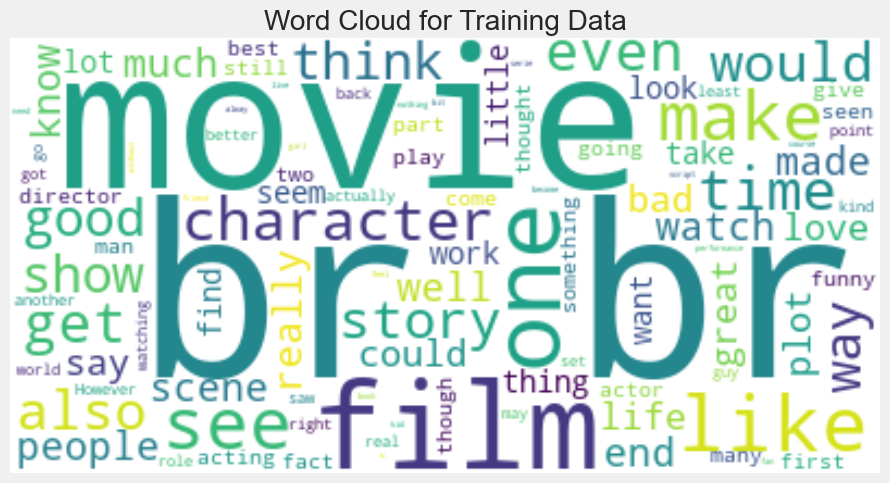

In [58]:
wordcloud = WordCloud(stopwords=stop_words, background_color="white", max_words=100).generate(' '.join(train_df['review']))

plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Training Data')
plt.show()

## Models

In [62]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
X_train = tfidf_vectorizer.fit_transform(train_df['review'])
X_test = tfidf_vectorizer.transform(test_df['review'])

y_train = train_df['sentiment'].map({'positive': 1, 'negative': 0}) 
y_test = test_df['sentiment'].map({'positive': 1, 'negative': 0})

### Baseline Model: Logistic Regression

In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# Predictions
y_pred_log_reg = log_reg.predict(X_test)

# Evaluation
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log_reg))
print(classification_report(y_test, y_pred_log_reg))

Logistic Regression Accuracy: 0.8654
              precision    recall  f1-score   support

           0       0.87      0.86      0.86      5000
           1       0.86      0.87      0.87      5000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



### Naive Bayes

In [64]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Predictions
y_pred_nb = nb_model.predict(X_test)

# Evaluation
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.8349
              precision    recall  f1-score   support

           0       0.84      0.82      0.83      5000
           1       0.83      0.85      0.84      5000

    accuracy                           0.83     10000
   macro avg       0.84      0.83      0.83     10000
weighted avg       0.84      0.83      0.83     10000



### Support Vector Machine (SVM)

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

# Predictions
y_pred_svm = svm_model.predict(X_test)

# Evaluation
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Logistic Regression offers competitive performance with simplicity and interpretability, it could be the preferred choice for ease of deployment and understanding and it has the accuracy of 86%.

Naive Bayes is very fast and performs well, making it a strong candidate when speed is a concern but has the accuracy of 83%, which cannot be accepted in our task.

Support Vector Machine (SVM) offers the best accuracy, but at the cost of computational efficiency and interpretability